In [1]:
from pathlib import Path
from shutil import rmtree
from math import ceil
from json import dumps
from typing import Literal
from pickle import Pickler
from gzip import open as gz_open
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer, make_column_selector

RANDOM_STATE = 12345

# Data

In [2]:
def get_sampling_strategy(y):
    class_names, class_counts = np.unique(y, return_counts=True)
    minority = class_counts.min()
    if len(class_names) == 2:
        target_size = min(minority, 4500)
        return {cls_name: target_size for cls_name in class_names}
    if len(class_names) == 8:
        return {cls_name: minority for cls_name in class_names}
    return {
        cls_name: min(50, class_counts[i] // minority) * minority
        for i, cls_name in enumerate(class_names)
    }


def prepare_experiment(
    which: Literal["full", "iot", "control", "infra"],
    target: Literal["binary", "grouped", "all"],
    overwrite: bool = False,
):
    experiment = {}
    dataset_path = Path("../datasense/dataset/")
    for split in ["train", "test"]:
        split_data = dataset_path / f"datasense_{which}_{split}_1sec.parquet"
        split_data = pd.read_parquet(split_data)
        if target == "binary":
            y_split = split_data["label1"]
        elif target == "grouped":
            y_split = split_data["label2"]
        else:
            y_split = split_data["label4"]
        experiment[split] = (split_data, y_split)
    experiment["num_classes"] = experiment["train"][1].nunique()
    if which == "full":
        experiment["transformers"] = make_column_transformer(
            ("drop", make_column_selector(r"^label")),
            (OneHotEncoder(), ["device_type"]),
            ("drop", make_column_selector(dtype_exclude=["number", "bool"])),
            remainder="passthrough",
            verbose_feature_names_out=False,
        )
    else:
        experiment["transformers"] = make_column_transformer(
            ("drop", make_column_selector(r"^label")),
            ("drop", make_column_selector(dtype_exclude=["number", "bool"])),
            remainder="passthrough",
            verbose_feature_names_out=False,
        )
    results_dir = Path("results")
    results_dir /= f"random_forest_{which}_{target}"
    if results_dir.is_dir():
        if overwrite:
            rmtree(results_dir, ignore_errors=True)
        else:
            raise RuntimeError("Experiment already executed and overwrite set to False")
    results_dir.mkdir(exist_ok=True, parents=True)
    cache_dir = results_dir / ".cache"
    cache_dir.mkdir()
    experiment["results_dir"] = results_dir
    experiment["cache_dir"] = str(cache_dir)
    return experiment

In [3]:
experiment = prepare_experiment(which="full", target="grouped")

X_train, y_train = experiment["train"]
X_test, y_test = experiment["test"]
results_dir = experiment["results_dir"]
cache_dir = experiment["cache_dir"]

# Experiment

## Training pipe

In [4]:
train_pipe = Pipeline(
    steps=[
        ("transformer", experiment["transformers"]),
        (
            "model",
            BalancedRandomForestClassifier(
                max_depth=6,
                bootstrap=False,
                replacement=True,
                sampling_strategy=get_sampling_strategy,
                random_state=RANDOM_STATE,
                class_weight="balanced_subsample",
            ),
        ),
    ],
    memory=cache_dir,
    verbose=False,
)

## Grid seach cross-validation

In [5]:
param_grid = {
    "model__criterion": ["gini", "entropy"],
    "model__n_estimators": [100, 150, 200, 250],
    "model__ccp_alpha": [0.0, 0.001, 0.01, 0.1],
}

In [6]:
grid = GridSearchCV(
    estimator=train_pipe,
    param_grid=param_grid,
    scoring=["balanced_accuracy", "f1_macro"],
    n_jobs=3,
    refit="f1_macro",
    cv=5,
    verbose=0,
    return_train_score=True,
)

grid.fit(X_train, y_train)

trained_pipe = grid.best_estimator_
trained_model = trained_pipe["model"]

## Cross-validation results

In [7]:
cv_results = pd.DataFrame(grid.cv_results_)
cv_results.sort_values(by="rank_test_f1_macro", inplace=True)
cv_results.to_csv(results_dir / "train_cv_results.csv", index=False)

## Feature importance

In [8]:
feature_names = trained_pipe["transformer"].get_feature_names_out()

feature_importances = pd.DataFrame({
    "feature": feature_names,
    "importance": trained_pipe["model"].feature_importances_,
})
feature_importances.sort_values(
    by="importance", ascending=False,
    ignore_index=True, inplace=True,
)
feature_importances.to_csv(results_dir / "feature_importances.csv", index=False)

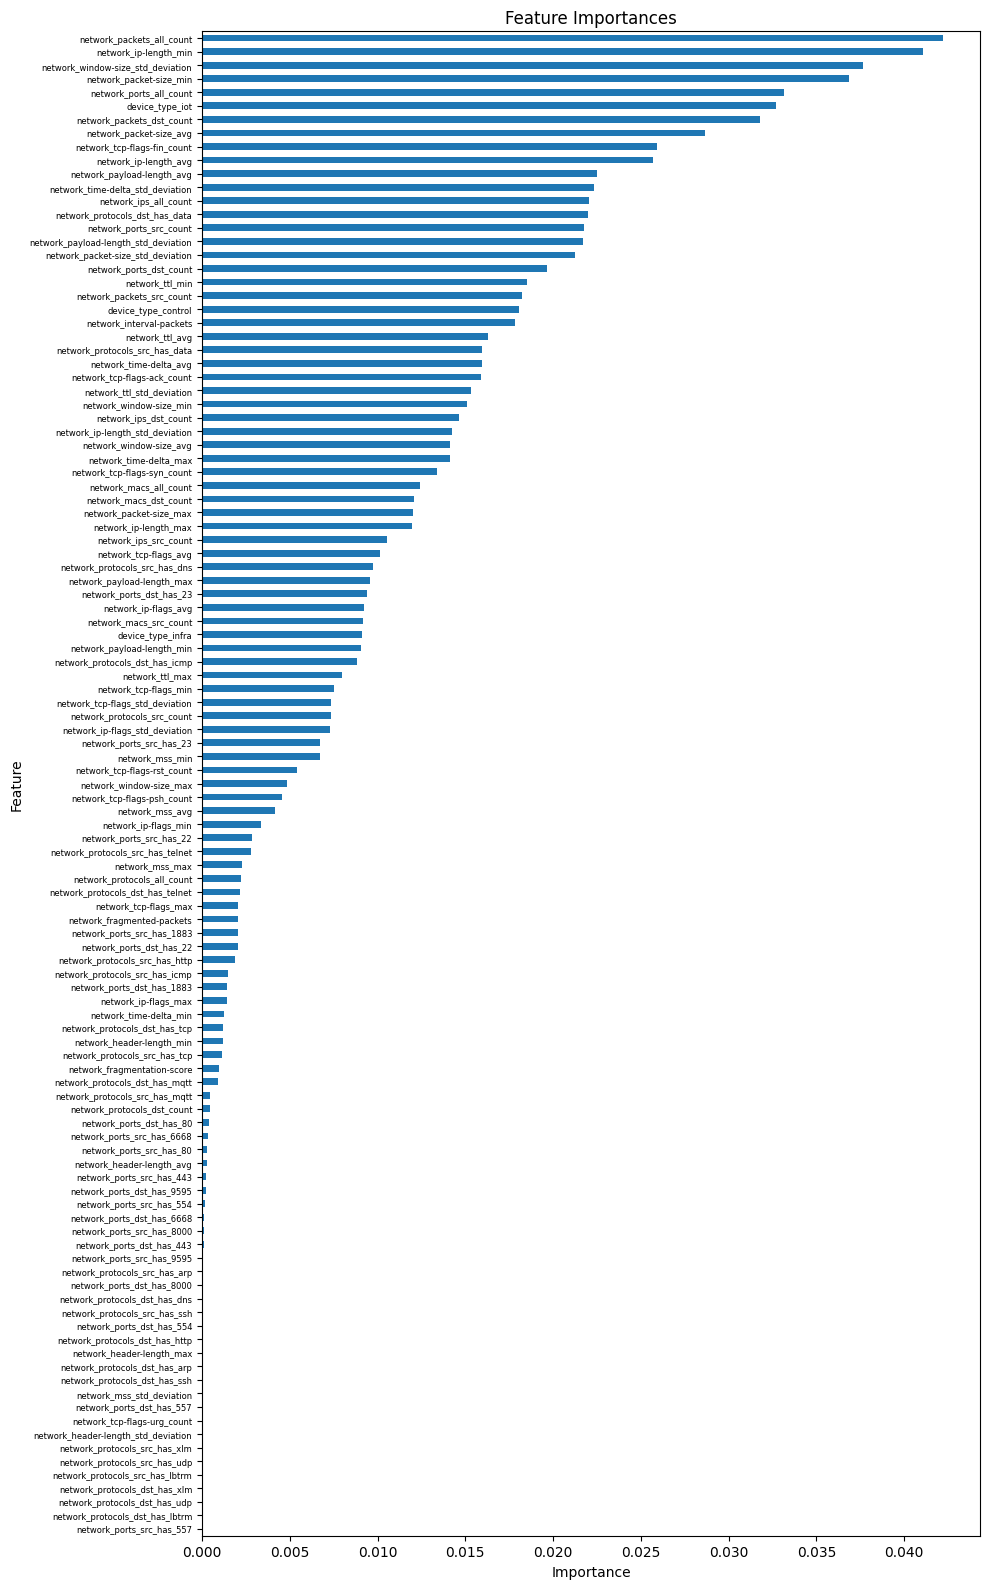

In [9]:
fig, ax = plt.subplots(figsize=(10, 16))

feature_importances["importance"].plot(kind="barh", ax=ax)

ax.invert_yaxis()
ax.set_yticks(
    ticks=range(feature_importances.shape[0]),
    labels=feature_importances["feature"],
    fontsize=6,
)
ax.set_title("Feature Importances")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.savefig(results_dir / "feature_importances.png", dpi=300)
plt.show()

# Model evaluations

## Train-split evaluations

In [10]:
y_proba = trained_pipe.predict_proba(X_train)

train_results = pd.DataFrame(
    data=y_proba,
    columns=trained_pipe.classes_,
    dtype="float32",
)

train_results.to_parquet(
    results_dir / "train_predict_proba.parquet",
    index=False,
    compression="gzip",
)

## Test-split evaluations

In [11]:
y_proba = trained_pipe.predict_proba(X_test)

test_results = pd.DataFrame(
    data=y_proba,
    columns=trained_pipe.classes_,
    dtype="float32",
)

test_results.to_parquet(
    results_dir / "test_predict_proba.parquet",
    index=False,
    compression="gzip",
)

# Model analysis and persistency

## Model persistency

In [12]:
trained_model.samplers_ = []
trained_model.pipelines_ = []

pipe_persist_path = results_dir / "pipe.pickle.gz"

with gz_open(pipe_persist_path, mode="wb") as pf:
    Pickler(pf, protocol=5).dump(trained_pipe)

## Model summary

In [13]:
total_n_nodes = sum(dtree.tree_.node_count for dtree in trained_model.estimators_)
total_n_leaves = sum(dtree.tree_.n_leaves for dtree in trained_model.estimators_)

model_summary = {
    "best_parameters": grid.best_params_,
    "all_parameters": trained_model.get_params(),
    "forest_structure": {
        "total_n_nodes": total_n_nodes,
        "mean_n_nodes": round(total_n_nodes / len(trained_model.estimators_), 2),
        "mean_n_leafs": round(total_n_leaves / len(trained_model.estimators_), 2),
    }
}

model_summary = dumps(model_summary, indent=2, default=str)
(results_dir / "model_summary.json").write_text(model_summary)
print("MODEL SUMMARY:", model_summary, sep="\n")

MODEL SUMMARY:
{
  "best_parameters": {
    "model__ccp_alpha": 0.0,
    "model__criterion": "gini",
    "model__n_estimators": 150
  },
  "all_parameters": {
    "bootstrap": false,
    "ccp_alpha": 0.0,
    "class_weight": "balanced_subsample",
    "criterion": "gini",
    "max_depth": 6,
    "max_features": "sqrt",
    "max_leaf_nodes": null,
    "max_samples": null,
    "min_impurity_decrease": 0.0,
    "min_samples_leaf": 1,
    "min_samples_split": 2,
    "min_weight_fraction_leaf": 0.0,
    "monotonic_cst": null,
    "n_estimators": 150,
    "n_jobs": null,
    "oob_score": false,
    "random_state": 12345,
    "replacement": true,
    "sampling_strategy": "<function get_sampling_strategy at 0x782090f1b420>",
    "verbose": 0,
    "warm_start": false
  },
  "forest_structure": {
    "total_n_nodes": 15722,
    "mean_n_nodes": 104.81,
    "mean_n_leafs": 52.91
  }
}
